## 0. Import libraries

In [ ]:
import os 
os.chdir('../..')

import numpy as np
import pandas as pd
import seaborn as sns
import tellurium as te
import re
import textwrap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools
import pickle

from mpl_toolkits.axes_grid1 import make_axes_locatable
from collections import defaultdict
from roadrunner import Config, Logger
from matplotlib.lines import Line2D

Logger.disableLogging()
Config.setValue(Config.ROADRUNNER_DISABLE_PYTHON_DYNAMIC_PROPERTIES, True)
Config.setValue(Config.LOADSBMLOPTIONS_RECOMPILE, False) 
Config.setValue(Config.LLJIT_OPTIMIZATION_LEVEL, 4)
Config.setValue(Config.LLVM_SYMBOL_CACHE, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_GVN, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_CFG_SIMPLIFICATION, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_INSTRUCTION_COMBINING, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_DEAD_INST_ELIMINATION, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_DEAD_CODE_ELIMINATION, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_INSTRUCTION_SIMPLIFIER, True)
Config.setValue(Config.SIMULATEOPTIONS_COPY_RESULT, True)

In [ ]:
rfit = te.loada(r'iMC057.txt')
rfit_atp_regen = te.loada(r'iMC057_plus_ATP_regen.txt')

model_rxns = pd.read_csv(r'Reactions.csv')

In [ ]:
with open(r'filtering_parameter_sets\final_params.pkl', 'rb') as file:
    trainparams = pickle.load(file)

In [ ]:
results_by_condition = defaultdict(list)

## Simulate pathway (base)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0.05 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.05 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.025 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.025 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = (10 / 1e-7 / d)
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["fullpath"].append(results[:, [0, 1, 2]])  # time + Malate

## Strategy 1 (increase pyruvate)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0.05 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.05 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.025 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.025 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = (10 / 1e-7 / d)
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
param_values['v53'] = (2 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["strat1"].append(results[:, [0, 1, 2]])  # time + Malate

## Strategy 2 (forgo Fdh and add more NADH)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.05 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.025 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.025 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = (10 / 1e-7 / d)
param_values['v44'] = (5 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["strat2"].append(results[:, [0, 1, 2]])  # time + Malate

## Strategy 3 (reallocate protein budget)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.068 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.015 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.068 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = (10 / 1e-7 / d)
param_values['v44'] = (5 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["strat3"].append(results[:, [0, 1, 2]])  # time + Malate

## Strategy 4 (omit HCT)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0.05 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.05 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.025 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.025 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = (0 / 1e-7 / d)
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["strat4"].append(results[:, [0, 1, 2]])  # time + Malate

## Strategy 5 (increase serine concentration)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0.05 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.05 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.025 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.025 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = (10 / 1e-7 / d)
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (20 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["strat5"].append(results[:, [0, 1, 2]])  # time + Malate

## Strategy 6 (Increase bicarbonate concentration)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0.05 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.05 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.025 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.025 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = (10 / 1e-7 / d)
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (20 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["strat6"].append(results[:, [0, 1, 2]])  # time + Malate

## Strategy 7 (overexpress MDH)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0.05 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.05 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (10 * preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.025 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.025 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = (10 / 1e-7 / d)
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["strat7"].append(results[:, [0, 1, 2]])  # time + Malate

## Strategy 8 (keep the same - do not knock out PEP carboxylase)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0.05 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.05 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.025 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.025 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = (10 / 1e-7 / d)
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["strat8"].append(results[:, [0, 1, 2]])  # time + Malate

## Strategy 9 (keep the same - advising against knockouts)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0.05 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.05 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.025 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.025 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = (10 / 1e-7 / d)
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["strat9"].append(results[:, [0, 1, 2]])  # time + Malate

## Strategy 10 (add an ATP regeneration system)

I have not implemented a change yet since i think i'll have to update the actual model file

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit_atp_regen.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit_atp_regen.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit_atp_regen.reset()

rel0 = rfit_atp_regen.rel0
rel1 = rfit_atp_regen.rel1
rel2 = rfit_atp_regen.rel2
rel3 = rfit_atp_regen.rel3
rel4 = rfit_atp_regen.rel4

preNADH = rfit_atp_regen.getValue('NADH')
preFormate = rfit_atp_regen.getValue('Formate')
prePyruvate = rfit_atp_regen.getValue('Pyruvate')
preATP = rfit_atp_regen.getValue('ATP')
preAcCoA = rfit_atp_regen.getValue('AcetylCoA')
preHCO3 = rfit_atp_regen.getValue('HCO3')
preAcetate = rfit_atp_regen.getValue('Acetate')
preMdh = rfit_atp_regen.getValue('eEC11137')
preSerine = rfit_atp_regen.getValue('L_Serine')

hEC11719 = 0.025 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.025 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.025 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.025 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

CHU0107 = 0.05 # atp regen
p_CHU0107 = (CHU0107 / (0.01 * d * rel4))


param_values['v73'] = (10 / 1e-7 / d)
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit_atp_regen.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53, 55],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117, p_CHU0107]
)

rfit_atp_regen.reset()

try:
    results = rfit_atp_regen.simulate(0, 4*60*60, selections=['time', 'SMalate', 'CO2'])
except RuntimeError:
    print('Cannot simulate')

rfit_atp_regen.resetToOrigin()

# Store formate vs. time
results_by_condition["strat10"].append(results[:, [0, 1, 2]])  # time + Malate

## Plotting

In [ ]:
mbase = results_by_condition['fullpath'][0][-1][1]
ms1 = results_by_condition['strat1'][0][-1][1]
ms2 = results_by_condition['strat2'][0][-1][1]
ms3 = results_by_condition['strat3'][0][-1][1]
ms4 = results_by_condition['strat4'][0][-1][1]
ms5 = results_by_condition['strat5'][0][-1][1]
ms6 = results_by_condition['strat6'][0][-1][1]
ms7 = results_by_condition['strat7'][0][-1][1]
ms8 = results_by_condition['strat8'][0][-1][1]
ms9 = results_by_condition['strat9'][0][-1][1]
ms10 = results_by_condition['strat10'][0][-1][1]

cbase = (results_by_condition['fullpath'][0][-1][2] - results_by_condition['fullpath'][0][0][2]) / (results_by_condition['fullpath'][0][-1][1] - results_by_condition['fullpath'][0][0][1])
cs1 = (results_by_condition['strat1'][0][-1][2] - results_by_condition['strat1'][0][0][2]) / (results_by_condition['strat1'][0][-1][1] - results_by_condition['strat1'][0][0][1])
cs2 = (results_by_condition['strat2'][0][-1][2] - results_by_condition['strat2'][0][0][2]) / (results_by_condition['strat2'][0][-1][1] - results_by_condition['strat2'][0][0][1])
cs3 = (results_by_condition['strat3'][0][-1][2] - results_by_condition['strat3'][0][0][2]) / (results_by_condition['strat3'][0][-1][1] - results_by_condition['strat3'][0][0][1])
cs4 = (results_by_condition['strat4'][0][-1][2] - results_by_condition['strat4'][0][0][2]) / (results_by_condition['strat4'][0][-1][1] - results_by_condition['strat4'][0][0][1])
cs5 = (results_by_condition['strat5'][0][-1][2] - results_by_condition['strat5'][0][0][2]) / (results_by_condition['strat5'][0][-1][1] - results_by_condition['strat5'][0][0][1])
cs6 = (results_by_condition['strat6'][0][-1][2] - results_by_condition['strat6'][0][0][2]) / (results_by_condition['strat6'][0][-1][1] - results_by_condition['strat6'][0][0][1])
cs7 = (results_by_condition['strat7'][0][-1][2] - results_by_condition['strat7'][0][0][2]) / (results_by_condition['strat7'][0][-1][1] - results_by_condition['strat7'][0][0][1])
cs8 = (results_by_condition['strat8'][0][-1][2] - results_by_condition['strat8'][0][0][2]) / (results_by_condition['strat8'][0][-1][1] - results_by_condition['strat8'][0][0][1])
cs9 = (results_by_condition['strat9'][0][-1][2] - results_by_condition['strat9'][0][0][2]) / (results_by_condition['strat9'][0][-1][1] - results_by_condition['strat9'][0][0][1])
cs10 = (results_by_condition['strat10'][0][-1][2] - results_by_condition['strat10'][0][0][2]) / (results_by_condition['strat10'][0][-1][1] - results_by_condition['strat10'][0][0][1])

C:\Users\mkcoo\AppData\Local\Temp\ipykernel_17092\2779552590.py:81: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



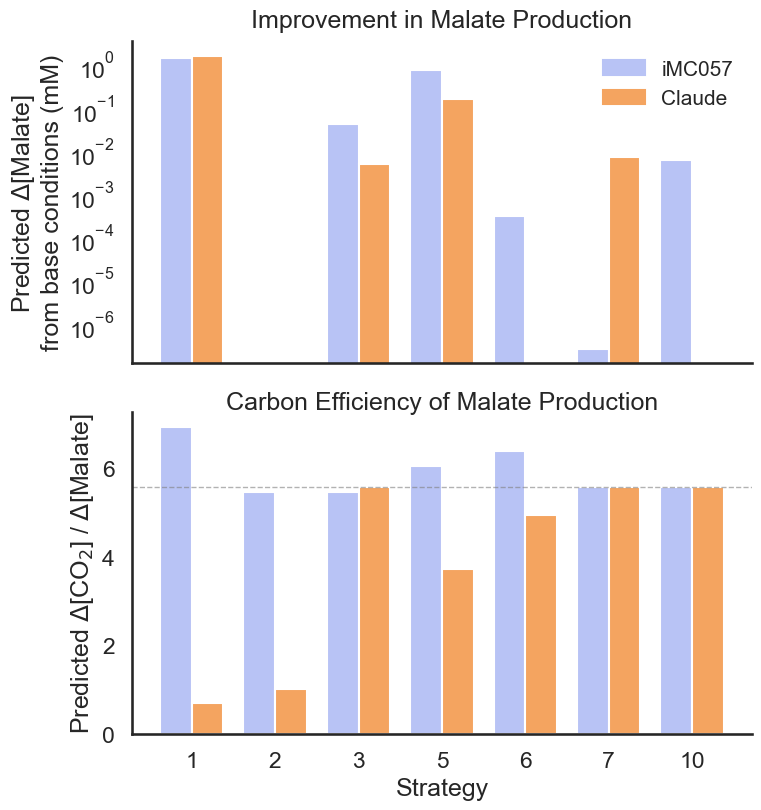

In [ ]:
# Data
categories = ['1', '2', '3', '5', '6', '7', '10']
malate = [ms1-mbase, ms2-mbase, ms3-mbase, ms5-mbase, ms6-mbase, ms7-mbase, ms10-mbase]
claude_mal = [mbase+1.58, mbase, mbase+0.005, mbase+0.16, mbase, mbase+0.007, mbase]
# claude_co2 = [cbase*7.9, cbase*5.5, cbase, cbase*1.5, cbase*1.13, cbase, cbase]
claude_co2 = [cbase/7.9, cbase/5.5, cbase, cbase/1.5, cbase/1.13, cbase, cbase]
ratio = [cs1, cs2, cs3, cs5, cs6, cs7, cs10]

df = pd.DataFrame({
    'Strategy': categories,
    'Malate': malate,
    'Ratio': ratio
})

# Style
sns.set_theme(style="white", context="talk")

# Create figure
fig, axes = plt.subplots(
    2, 1,
    figsize=(8, 9),
    sharex=True,
    gridspec_kw={'hspace': 0.15}
)

x = np.arange(len(categories))
w = 0.38
bar_color  = '#B8C3F5'
claude_color = '#F4A460'

# --- Top: Malate ---
for i, mal in enumerate(malate):
    axes[0].bar(x[i] - w / 2, mal, w, color=bar_color)

claude_delta = [val - mbase for val in claude_mal]
for i, delta in enumerate(claude_delta):
    axes[0].bar(x[i] + w / 2, delta, w, color=claude_color)

axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel('Predicted $\\Delta$[Malate]\nfrom base conditions (mM)')
axes[0].set_yscale('log')
axes[0].set_title('Improvement in Malate Production', pad=10)
axes[0].spines[['top', 'right']].set_visible(False)

sim_patch    = mpatches.Patch(color=bar_color, label='iMC057')
claude_patch = mpatches.Patch(color=claude_color, label='Claude')
axes[0].legend(handles=[sim_patch, claude_patch], frameon=False, fontsize='small')

# --- Bottom: Ratio ---
for i, rat in enumerate(ratio):
    axes[1].bar(x[i] - w / 2, rat, w, color=bar_color)

claude_delta_r = [val for val in claude_co2]
for i, delta in enumerate(claude_delta_r):
    axes[1].bar(x[i] + w / 2, delta, w, color=claude_color)

axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Predicted $\\Delta$[CO$_2$] / $\\Delta$[Malate]')
# axes[1].set_yscale('log')
axes[1].axhline(cbase, linestyle='--', linewidth=1, color='gray', alpha=0.6)
axes[1].set_xlabel('Strategy')
axes[1].set_title('Carbon Efficiency of Malate Production', pad=2)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(axis='x', rotation=0)

# base_line = Line2D([0], [0], linestyle='--', linewidth=1, color='gray', alpha=0.6, label='Base $\\Delta$[CO$_2$] / $\\Delta$[Malate]')
# axes[0] legend only, with all three handles
axes[0].legend(handles=[sim_patch, claude_patch], frameon=False, fontsize='small')

plt.tight_layout()
plt.savefig('Figures/Figure_6.svg')
plt.show()